In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r'/home/quan-pc/Documents/Document/KPDL/Lab 2-Data Preprocessing/Bengaluru_House_Data.csv'
df_raw = pd.read_csv(path)
df_raw.shape

(13320, 9)

xem 5 mau dau tien

In [3]:
df_raw.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


xem 5 mau cuoi cung

In [4]:
df_raw.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


Phan tich tham do

In [5]:
df = df_raw.copy()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


Thong ke mot so thuoc tinh co ban

In [7]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


Thong ke cac gia tri duy nhat cua tung truong va so lan xuat hien cua chung

In [8]:
def value_count(df):
    for var in df.columns:
        print(df[var].value_counts().to_string())
        print("\n")
value_count(df)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87


availability
Ready To Move           10581
18-Dec                    307
18-May                    295
18-Apr                    271
18-Aug                    200
19-Dec                    185
18-Jul                    143
18-Mar                    131
18-Jun                     99
20-Dec                     98
21-Dec                     93
19-Mar                     88
18-Feb                     62
18-Nov                     47
18-Jan                     43
18-Sep                     41
19-Jun                     40
18-Oct                     39
19-Jan                     39
19-Jul                     36
17-Dec                     29
20-Jan                     24
19-Sep                     21
17-Oct                     21
22-Jun                     19
19-Aug                     18
21-Jun                     17
Immediate Possession       16
20-Aug             

xem xét tương quan về  giá trị của các cặp trường số

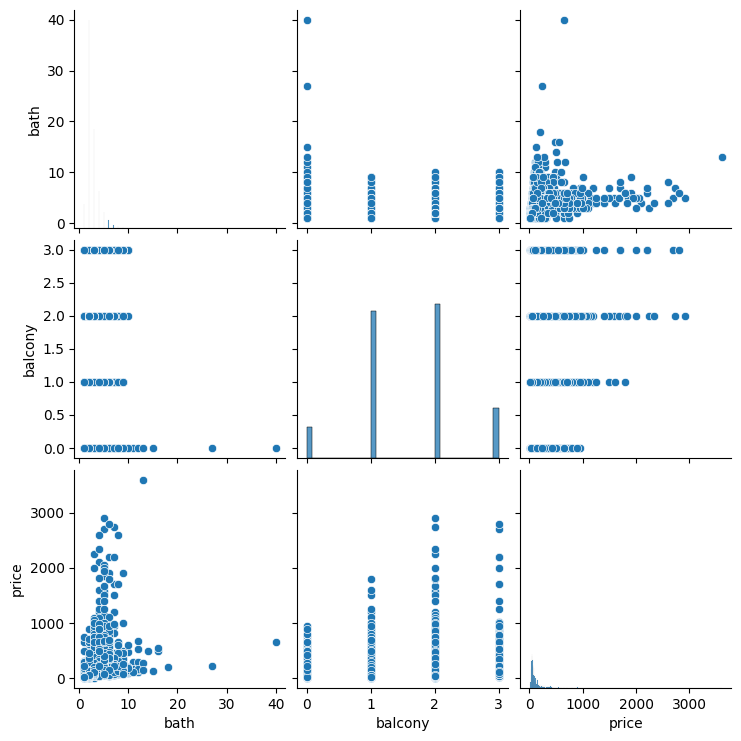

In [9]:
sns.pairplot(df)

<Axes: >

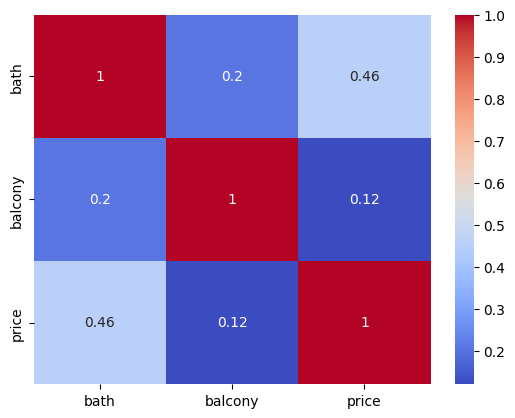

In [10]:
num_vars = ["bath", "balcony","price"]
sns.heatmap(df[num_vars].corr(), annot=True, cmap="coolwarm")

Tiển xử  lý dữ liệu

1. thống kê giá trị null của từng thuộc tính

In [11]:
df.isnull().mean() * 100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

2. loại đi trường society vì tỷ lệ null cao

In [12]:
df2 = df.drop('society', axis='columns')
df2.shape

(13320, 8)

In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   total_sqft    13320 non-null  object 
 5   bath          13247 non-null  float64
 6   balcony       12711 non-null  float64
 7   price         13320 non-null  float64
dtypes: float64(3), object(5)
memory usage: 832.6+ KB


3. thay thế giá trị null trong trương balcony bằng giá trị trung bình của các giá trị non-null

In [15]:
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

In [17]:
# xóa đi các mau NaN
df3 = df2.dropna()
df3.shape

(13246, 8)

In [18]:
# Thong kê lại
df3.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

xử lí các trương mà có dữ liệu là string ...

In [20]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13246 entries, 0 to 13319
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13246 non-null  object 
 1   availability  13246 non-null  object 
 2   location      13246 non-null  object 
 3   size          13246 non-null  object 
 4   total_sqft    13246 non-null  object 
 5   bath          13246 non-null  float64
 6   balcony       13246 non-null  float64
 7   price         13246 non-null  float64
dtypes: float64(3), object(5)
memory usage: 931.4+ KB


In [23]:
# trường total_sqft
df3['total_sqft'].value_counts()

total_sqft
1200     843
1100     221
1500     204
2400     195
600      180
        ... 
2383       1
4830       1
555        1
785        1
804.1      1
Name: count, Length: 2067, dtype: int64

In [24]:
total_sqft_float=[]
for str_val in df3['total_sqft']:
    try:
        # thử nếu chuyển được về float
        total_sqft_float.append(float(str_val))
    except:
        # nếu lỗi 
        try:
            temp = [] # tạo mảng tạm
            temp = str_val.split('-') # tách chuỗi tại dấu '-'
            total_sqft_float.append((float(temp[0]) + float(temp[1]))/2) # lấy trung bình 2 số
        except:
            total_sqft_float.append(np.nan) # Nếu là khác thì gán nà NaN missing value

df4 = df3.reset_index(drop=True) # reset lại index

In [25]:
# thêm trương total_sqft_float vào df4
df5 = df4.join(pd.DataFrame(total_sqft_float, columns=['total_sqft_float']))
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [28]:
df5 = df5.drop('total_sqft', axis='columns')
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13246 entries, 0 to 13245
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13246 non-null  object 
 1   availability      13246 non-null  object 
 2   location          13246 non-null  object 
 3   size              13246 non-null  object 
 4   bath              13246 non-null  float64
 5   balcony           13246 non-null  float64
 6   price             13246 non-null  float64
 7   total_sqft_float  13200 non-null  float64
dtypes: float64(4), object(4)
memory usage: 828.0+ KB


In [29]:
df5_copy = df5.copy()

In [31]:
cols = list(df5_copy.columns.values)
print(cols) 

['area_type', 'availability', 'location', 'size', 'bath', 'balcony', 'price', 'total_sqft_float']


In [32]:
df5_copy[cols[0:4] + [cols[-1]] + cols[4:-1]].head()

,area_type,availability,location,size,total_sqft_float,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056.0,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600.0,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440.0,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521.0,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200.0,2.0,1.0,51.00


In [33]:
# xem lạicác giá trị null
df5_copy.isnull().sum()

area_type            0
availability         0
location             0
size                 0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [34]:
df6 = df5_copy.dropna()
df6.shape

(13200, 8)

In [35]:
# xem lai thông tin
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13245
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  object 
 1   availability      13200 non-null  object 
 2   location          13200 non-null  object 
 3   size              13200 non-null  object 
 4   bath              13200 non-null  float64
 5   balcony           13200 non-null  float64
 6   price             13200 non-null  float64
 7   total_sqft_float  13200 non-null  float64
dtypes: float64(4), object(4)
memory usage: 928.1+ KB


2. làm việc với thuộc tính size

In [36]:
df6['size'].value_counts()

size
2 BHK         5192
3 BHK         4277
4 Bedroom      816
4 BHK          574
3 Bedroom      541
1 BHK          527
2 Bedroom      325
5 Bedroom      293
6 Bedroom      190
1 Bedroom      100
8 Bedroom       83
7 Bedroom       83
5 BHK           56
9 Bedroom       45
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            7
8 BHK            5
11 BHK           2
10 BHK           2
11 Bedroom       2
27 BHK           1
19 BHK           1
43 Bedroom       1
16 BHK           1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64